In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from collector import BASE_PATH

In [22]:
PRICE_PLOT_KWARGS = {"xlim": (0,1)}


df = pd.read_parquet(f"{BASE_PATH}/data/dataframe.parquet")

df = df.drop(columns = ['icon','bio','profileImage','profileImageOptimized'])

print(df.info())

print(f"Maximum event_id: {max(df.event_id)}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950367 entries, 0 to 1950366
Data columns (total 17 columns):
 #   Column           Dtype  
---  ------           -----  
 0   event_id         int64  
 1   trade_index      int64  
 2   proxyWallet      object 
 3   side             object 
 4   asset            object 
 5   conditionId      object 
 6   size             float64
 7   price            float64
 8   timestamp        int64  
 9   title            object 
 10  slug             object 
 11  eventSlug        object 
 12  outcome          object 
 13  outcomeIndex     int64  
 14  name             object 
 15  pseudonym        object 
 16  transactionHash  object 
dtypes: float64(2), int64(4), object(11)
memory usage: 253.0+ MB
None
Maximum event_id: 5971


<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1000 non-null   int64  
 1   trade_index      1000 non-null   int64  
 2   proxyWallet      1000 non-null   object 
 3   side             1000 non-null   object 
 4   asset            1000 non-null   object 
 5   conditionId      1000 non-null   object 
 6   size             1000 non-null   float64
 7   price            1000 non-null   float64
 8   timestamp        1000 non-null   int64  
 9   title            1000 non-null   object 
 10  slug             1000 non-null   object 
 11  eventSlug        1000 non-null   object 
 12  outcome          1000 non-null   object 
 13  outcomeIndex     1000 non-null   int64  
 14  name             1000 non-null   object 
 15  pseudonym        1000 non-null   object 
 16  transactionHash  1000 non-null   object 
 17  value            100

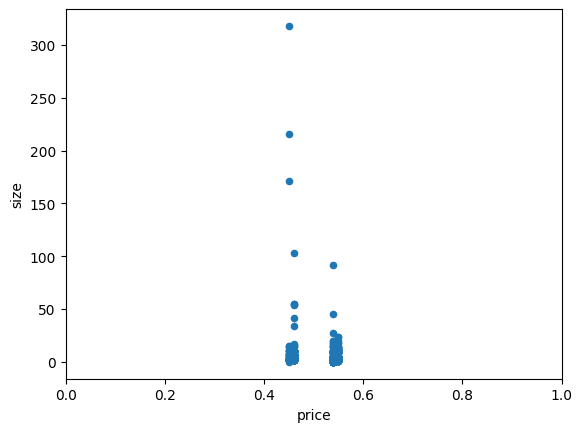

price, size: [0.45, 318.0], 
value: 143.1, 
z-score: 20.89, 
event mean: 2.035502655


1

In [40]:


def fun(num : int):
    
    event = df.loc[df.event_id == num].copy()

    if event.loc[df.event_id == num].empty: 
        print("\n --------------Empty series---------------- \n")
        return 0
    
    event['value'] = event['price']*event['size']
    event['price_size_list'] = event[['price','size']].values.tolist()

    event_mean = event['value'].mean() 

    event['z_score'] = abs((event['value']-event_mean)/(event['value'].std()))
    
    print(event.info())
    print(event.z_score)
    
    event.plot.scatter(x="price",y="size", **PRICE_PLOT_KWARGS)
    
    plt.show()
    
    max_row = event.loc[event['value'].idxmax()]
    
    print(
        f"price, size: {max_row['price_size_list']}, \n"
        f"value: {max_row['value']}, \n"
        f"z-score: {max_row['z_score']:.2f}, \n"
        f"event mean: {event_mean}"
    )

    return 1

fun(0)



 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 


 --------------Empty series---------------- 

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1293678 to 1294677
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1000 non-null   int64  
 1   trade_index      1000 non-null   int64  
 2   proxyWallet      1000 non-null   object 
 3   side             1000 non-null   object 
 4   asset            1000 non-null   object 
 5   conditionId      1000 non-null   object 
 6   size             1000 non-null   float64
 7   price            1000 non-null   float64
 8   timestamp        1000 non-null   int64  
 9   ti

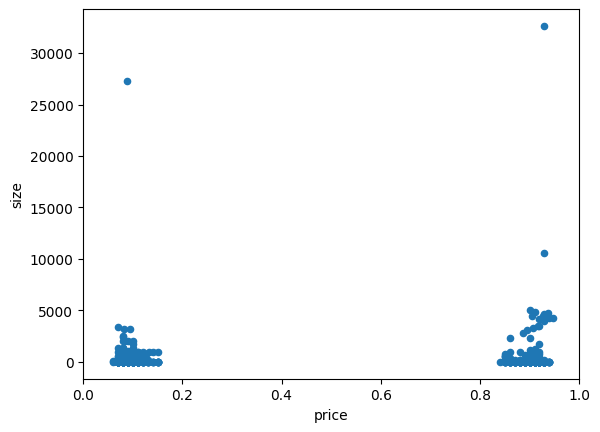

price, size: [0.9293351120708832, 32637.38], 
value: 30331.0632, 
z-score: 27.08, 
event mean: 135.690966239
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1294678 to 1295677
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         1000 non-null   int64  
 1   trade_index      1000 non-null   int64  
 2   proxyWallet      1000 non-null   object 
 3   side             1000 non-null   object 
 4   asset            1000 non-null   object 
 5   conditionId      1000 non-null   object 
 6   size             1000 non-null   float64
 7   price            1000 non-null   float64
 8   timestamp        1000 non-null   int64  
 9   title            1000 non-null   object 
 10  slug             1000 non-null   object 
 11  eventSlug        1000 non-null   object 
 12  outcome          1000 non-null   object 
 13  outcomeIndex     1000 non-null   int64  
 14  name             1000 non-null   object

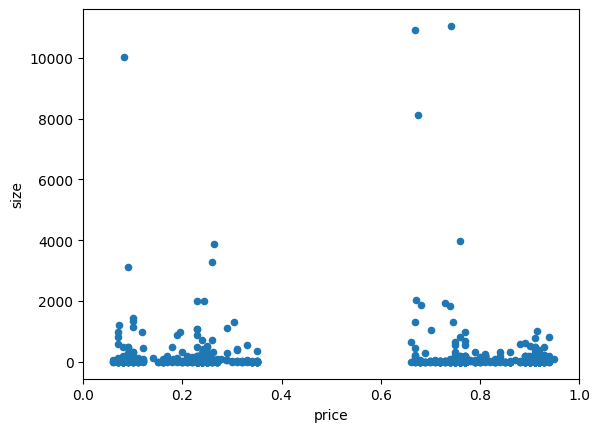

price, size: [0.7412217679118913, 11047.27], 
value: 8188.477, 
z-score: 19.35, 
event mean: 70.49864292


In [41]:
for i in range(10):
    fun(i+4000)